# Predicting House Prices

### Overview
This dataset is about houses and their features: when they were buit, how many rooms, etc. The goal is to predict each house's price.

# Setup Kaggle API and download dataset

In [ ]:
from google.colab import files  #uploading kaggle.json so that kaggle API is set and authenticated(I would be able to download kaggle datasets directly withoput google drive)
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"selmachelbabi","key":"182db91e93122321f0e7539d6fca0680"}'}

In [ ]:
import os # creates kaggle configuration folder, moves API key there and secures the file

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip house-prices-advanced-regression-techniques.zip

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


#Reading & Cleaning Data

In [ ]:
import pandas as pd
df=pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
df.dtypes


,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [ ]:
# drop duplicates and remove ID since we dont need it
df=df.drop_duplicates()
df=df.drop('Id',axis=1)
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
#remove the target and put it in y
x=df.drop('SalePrice',axis=1)
y=df['SalePrice']
x

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [ ]:
#checks for how many null values are in each column
x.isnull().sum()[x.isnull().sum()>0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
# PoolQC, Fence, MiscFeature, and Alley contain a very high percentage
# of missing values, so they were removed to reduce noise and simplify
# preprocessing.
x=x.drop('PoolQC',axis=1)
x=x.drop('Fence',axis=1)
x=x.drop('MiscFeature',axis=1)
x=x.drop('Alley',axis=1)
x

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,84,0,0,0,0,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,40,0,0,0,0,0,8,2007,WD,Normal
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,2,2010,WD,Normal
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,60,0,0,0,0,2500,5,2010,WD,Normal
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,112,0,0,0,0,4,2010,WD,Normal


In [ ]:
#checking if bsmtfintype 1&2 have unique values
print(x["BsmtFinType1"].unique())
print(x["BsmtFinType2"].unique())


['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' nan 'LwQ']
['Unf' 'BLQ' nan 'ALQ' 'Rec' 'LwQ' 'GLQ']


In [ ]:
#feature engineering
#combining bsmt fintype 1&2 into one and then removing them cuz they are very similar
finish_types={
    "GLQ":6,
    "ALQ":5,
    "BLQ":4,
    "REC":3,
    "LwQ":2,
    "Unf":1
}
x["BsmtFinType1_num"]=x["BsmtFinType1"].map(finish_types).fillna(0)
x["BsmtFinType2_num"]=x["BsmtFinType2"].map(finish_types).fillna(0)
x["QualBsmtFinType"]=(x["BsmtFinType1_num"]+x["BsmtFinType2_num"])/2
print(x["QualBsmtFinType"])

0       3.5
1       3.0
2       3.5
3       3.0
4       3.5
       ... 
1455    1.0
1456    2.5
1457    3.5
1458    3.0
1459    3.0
Name: QualBsmtFinType, Length: 1460, dtype: float64


In [ ]:
#drop BsmtFinType 1&2 cuz we no longer need them
x=x.drop('BsmtFinType1',axis=1)
x=x.drop('BsmtFinType2',axis=1)
x=x.drop('BsmtFinType1_num',axis=1)
x=x.drop('BsmtFinType2_num',axis=1)
x

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,QualBsmtFinType
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,3.5
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,3.0
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,3.5
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,3.0
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,1.0
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,2.5
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,3.5
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,3.0


In [ ]:
#Inspect categorical levels before ordinal encoding
print(x["GarageCond"].unique())
print(x["GarageQual"].unique())

['TA' 'Fa' nan 'Gd' 'Po' 'Ex']
['TA' 'Fa' 'Gd' nan 'Ex' 'Po']


In [ ]:
# feature engineering
# im going to combine exterior1st &  exterior2nd since they are both similar
x["exterior_material"]=x["Exterior1st"].astype(str)+"_"+x["Exterior2nd"].astype(str)
Garage_Q={
    "Ex":5,
    "Gd":4,
    "TA":3,
    "Fa":2,
    "Po":1,
    "Na":0
}
x["GarageCond_num"]=x["GarageCond"].map(Garage_Q)
x["GarageQual_num"]=x["GarageQual"].map(Garage_Q)
x["OverallGarageQ"]=(x["GarageCond_num"]+x["GarageQual_num"])/2
x=x.drop('GarageCond',axis=1)
x=x.drop('GarageQual',axis=1)
x=x.drop('GarageCond_num',axis=1)
x=x.drop('GarageQual_num',axis=1)


In [ ]:
#feature engineering
x["AllFullbath"]=x["FullBath"]+x["BsmtFullBath"]
x["AllHalfbath"]=x["BsmtHalfBath"]+x["HalfBath"]
x=x.drop("FullBath",axis=1)
x=x.drop("BsmtFullBath",axis=1)
x=x.drop("HalfBath",axis=1)
x=x.drop("BsmtHalfBath",axis=1)

In [ ]:
#feature engineering
x["Exteriortype"]=x["Exterior1st"]+x["Exterior2nd"]
x=x.drop("Exterior1st",axis=1)
x=x.drop("Exterior2nd",axis=1)

In [ ]:
#feature engineering
x["TotalBsmtFinsf"]=x["BsmtFinSF1"]+x["BsmtFinSF2"]
x=x.drop("BsmtFinSF1",axis=1)
x=x.drop("BsmtFinSF2",axis=1)



*   I've tried to add more features like: house age, remodeling age, and total SF but they made the predictions worse so i decided against them.



In [ ]:
#split the data into train test split and split the columns into numerical and categorical ones
import numpy as np

num_cols_test =[col for col in x.select_dtypes(include=[np.number]).columns if col !="GarageYrBlt"]
Ordinal_cat=["ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC","KitchenQual","FireplaceQu","BsmtExposure"]
cat_cols = [col for col in x.select_dtypes(include=['object','category']).columns if col not in Ordinal_cat]

#These were diveded into such columns after exploring the histograms
excluded_cols=["GarageYrBlt","MSSubClass", "LotFrontage","YearBuilt","BsmtUnfSF","TotalBsmtSF","1stFlrSF","GrLivArea"]
num_cols_nonskewed=[col for col in x.select_dtypes(include=[np.number]).columns if col not in excluded_cols]
num_cols_skewed=["MSSubClass", "LotFrontage","YearBuilt","BsmtUnfSF","TotalBsmtSF","1stFlrSF","GrLivArea"]

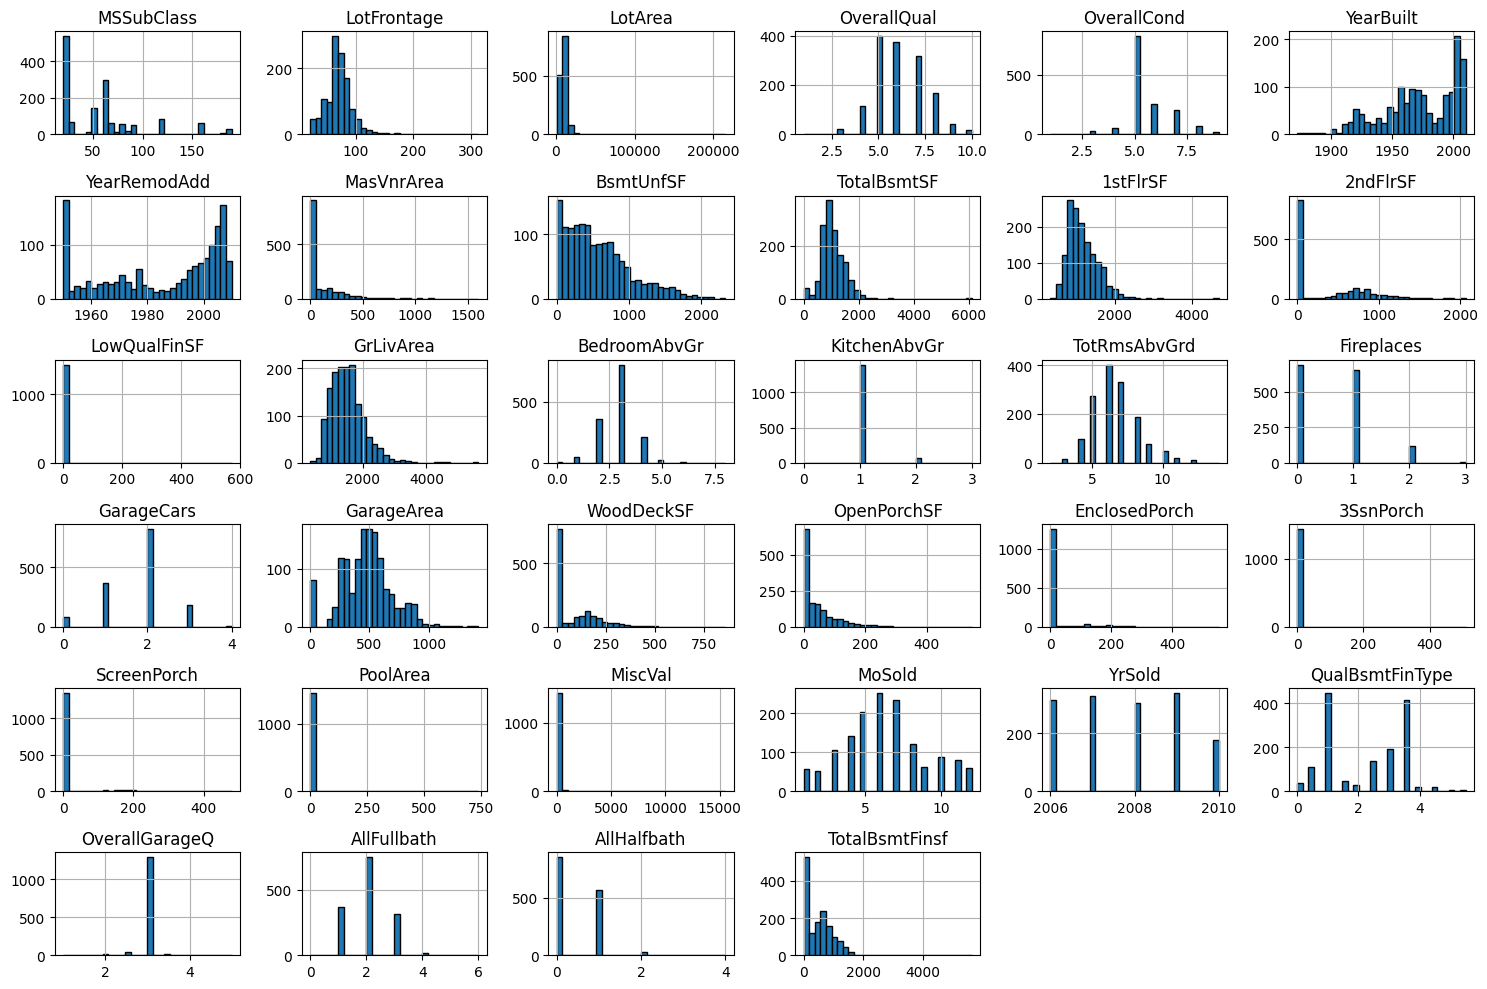

In [ ]:
# using histograms to check for outliers and data skewness
import matplotlib.pyplot as plt
x[num_cols_test].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()



*   Here I've tried figuring out the outliers and replacing them with the medians of their respected columns but the predictions of the model became worse so i decided to ignore them.




In [ ]:
"""columns = num_cols_test
outlier_percentage = {}

for column in columns:
    column_data = x[column].dropna()

    Q1 = np.percentile(column_data, 25)
    Q3 = np.percentile(column_data, 75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = column_data[(column_data < lower) | (column_data > upper)]
    outlier_percentage[column] = len(outliers) / len(column_data) * 100

    print(f"Count of outliers in column '{column}': {len(outliers)}")
    print(f"Percentage of outliers in column '{column}':{outlier_percentage[column]:.2f}%")
    print()
    print(f"Lower : {lower}")
    print(f"Upper : {upper}")
    print()
    print(f"Data Outlier': {np.array(outliers)}")"""

'columns = num_cols_test\noutlier_percentage = {}\n\nfor column in columns:\n    column_data = x[column].dropna()\n\n    Q1 = np.percentile(column_data, 25)\n    Q3 = np.percentile(column_data, 75)\n    IQR = Q3 - Q1\n\n    lower = Q1 - 1.5 * IQR\n    upper = Q3 + 1.5 * IQR\n\n    outliers = column_data[(column_data < lower) | (column_data > upper)]\n    outlier_percentage[column] = len(outliers) / len(column_data) * 100\n\n    print(f"Count of outliers in column \'{column}\': {len(outliers)}")\n    print(f"Percentage of outliers in column \'{column}\':{outlier_percentage[column]:.2f}%")\n    print()\n    print(f"Lower : {lower}")\n    print(f"Upper : {upper}")\n    print()\n    print(f"Data Outlier\': {np.array(outliers)}")'

In [ ]:
"""df_median = x.copy()

for column in columns:

    Q1 = df_median[column].quantile(0.25)
    Q3 = df_median[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df_median[column].median()

    condition = (
        (df_median[column] < lower) |
        (df_median[column] > upper)
    )

    df_median.loc[condition, column] = median

    outliers = df_median.loc[condition, column]

    print(f"{column}: {len(outliers)} outliers replaced")
    x=df_median """

'df_median = x.copy()\n\nfor column in columns:\n\n    Q1 = df_median[column].quantile(0.25)\n    Q3 = df_median[column].quantile(0.75)\n\n    IQR = Q3 - Q1\n\n    lower = Q1 - 1.5 * IQR\n    upper = Q3 + 1.5 * IQR\n\n    median = df_median[column].median()\n\n    condition = (\n        (df_median[column] < lower) |\n        (df_median[column] > upper)\n    )\n\n    df_median.loc[condition, column] = median\n\n    outliers = df_median.loc[condition, column]\n\n    print(f"{column}: {len(outliers)} outliers replaced")\n    x=df_median '

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


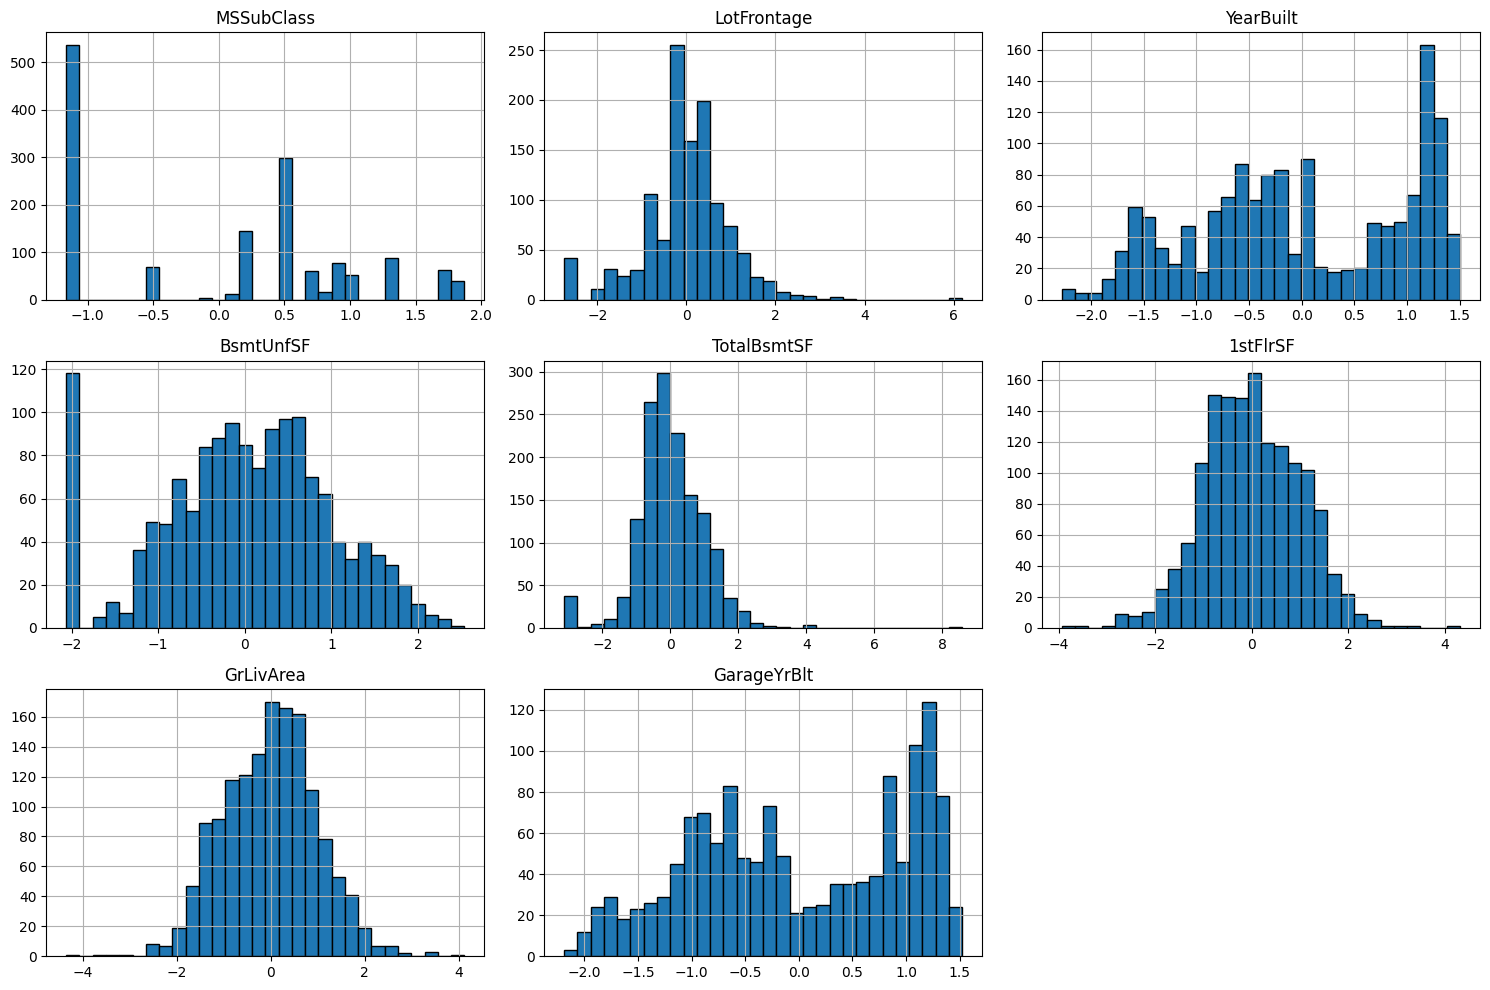

In [ ]:
#yeo-johnson will be used to deal with skewed data.
from sklearn.preprocessing import PowerTransformer
data_totransform=x[["MSSubClass", "LotFrontage","YearBuilt","BsmtUnfSF","TotalBsmtSF","1stFlrSF","GrLivArea",
                   "GarageYrBlt"]].copy()
pt=PowerTransformer(method="yeo-johnson")
data_tranformed=pt.fit_transform(data_totransform)
transformed= pd.DataFrame(data_tranformed,columns=data_totransform.columns)
transformed.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

In [ ]:
# Dealing with Ordinal categories
print(x["ExterQual"].unique())
print(x["ExterCond"].unique())
print(x["BsmtQual"].unique())
print(x["BsmtCond"].unique())
print(x["BsmtExposure"].unique())
print(x["HeatingQC"].unique())
print(x["KitchenQual"].unique())
print(x["FireplaceQu"].unique())

# a quality order as well as an exposure order will be made to just plug it in the ordinal encoder
quality_order=['Po','Fa','TA','Gd','Ex']
exposure_order=['No','Mn','Av','Gd']
categories=[quality_order,quality_order,quality_order,quality_order,quality_order,quality_order,quality_order,exposure_order]

['Gd' 'TA' 'Ex' 'Fa']
['TA' 'Gd' 'Fa' 'Po' 'Ex']
['Gd' 'TA' 'Ex' nan 'Fa']
['TA' 'Gd' nan 'Fa' 'Po']
['No' 'Gd' 'Mn' 'Av' nan]
['Ex' 'Gd' 'TA' 'Fa' 'Po']
['Gd' 'TA' 'Ex' 'Fa']
[nan 'TA' 'Gd' 'Fa' 'Ex' 'Po']


# Pipeline & Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
# constant pipeline with an imputer that fills with a constant
constant_cols=["GarageYrBlt"]
constant_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="constant", fill_value=0)),
    ("transformer",PowerTransformer(method="yeo-johnson"))
    #("scaler",StandardScaler())
])
# a pipline for skewed data so that it will be transformed
skewed_pipe=Pipeline([
   ("imputer",SimpleImputer(strategy="median")),
   ("transformer",PowerTransformer(method="yeo-johnson"))
   #("scaler",StandardScaler())
])
# a pipeline for non skewed data so that it wont be transformed
nonskewed_pipe=Pipeline([
   ("imputer",SimpleImputer(strategy="median")),
   ("scaler",RobustScaler())
])
# a pipeline for nominal categorical values
cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
# a pipeline for ordinal categorical values
ordinal_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OrdinalEncoder(categories=categories,handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor=ColumnTransformer([
    ('skewed',skewed_pipe,num_cols_skewed),
    ('nonskewed',nonskewed_pipe,num_cols_nonskewed),
    ('constant',constant_pipe,constant_cols),
    ('cat',cat_pipe,cat_cols),
    ('ordinal',ordinal_pipe,Ordinal_cat)
])
# y was transformed because its skewed and because we're using ridge and it does get affected
y = np.log1p(df['SalePrice'])

In [ ]:
#model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,train_size=0.7,random_state=42,shuffle=True)
model_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',ElasticNet())
])

param_grid = {
    'model__alpha': [0.00001,0.00005,0.0005,0.0001, 0.001, 0.01, 0.1, 1],
    'model__l1_ratio': [ 0.0001,0.0005,0.001,0.005,0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    estimator=model_pipe,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid.fit(x_train,y_train)
prediction=grid.predict(x_test)
preds = np.expm1(prediction)
y_test_original = np.expm1(y_test)
rmse=root_mean_squared_error(y_test_original,preds)
r2=r2_score(y_test_original,preds)
mae=mean_absolute_error(y_test_original,preds)
print("rmse: ",rmse)
print("r2_score: ",r2)
print("mae: ",mae)

rmse:  22284.110755037742
r2_score:  0.9288370708168953
mae:  14039.156160163497


The target y was transformed because at first the rmse and r2_score indicated that the model valued the huge prices of houses and put too much importance to them. But after the transformation the rmse and r2_score got better since it helped the model not penalize and focus on huge prices.

# Test Model

Mirror the same things you did to the train dataset

In [ ]:
dt=pd.read_csv('test.csv')
dt

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [ ]:
dt=dt.drop_duplicates()
ID=dt['Id']
dt=dt.drop('Id',axis=1)
dt=dt.drop('PoolQC',axis=1)
dt=dt.drop('Fence',axis=1)
dt=dt.drop('MiscFeature',axis=1)
dt=dt.drop('Alley',axis=1)


In [ ]:
finish_types={
    "GLQ":6,
    "ALQ":5,
    "BLQ":4,
    "REC":3,
    "LwQ":2,
    "unf":1
}
dt["BsmtFinType1_num"]=dt["BsmtFinType1"].map(finish_types).fillna(0)
dt["BsmtFinType2_num"]=dt["BsmtFinType2"].map(finish_types).fillna(0)
dt["QualBsmtFinType"]=(dt["BsmtFinType1_num"]+dt["BsmtFinType2_num"])/2
print(dt["QualBsmtFinType"])
dt=dt.drop('BsmtFinType1',axis=1)
dt=dt.drop('BsmtFinType2',axis=1)
dt=dt.drop('BsmtFinType1_num',axis=1)
dt=dt.drop('BsmtFinType2_num',axis=1)

dt["exterior_material"]=dt["Exterior1st"].astype(str)+"_"+dt["Exterior2nd"].astype(str)
Garage_Q={
    "Ex":5,
    "Gd":4,
    "TA":3,
    "Fa":2,
    "Po":1,
    "Na":0
}
dt["GarageCond_num"]=dt["GarageCond"].map(Garage_Q)
dt["GarageQual_num"]=dt["GarageQual"].map(Garage_Q)
dt["OverallGarageQ"]=(dt["GarageCond_num"]+dt["GarageQual_num"])/2
dt=dt.drop('GarageCond',axis=1)
dt=dt.drop('GarageQual',axis=1)
dt=dt.drop('GarageCond_num',axis=1)
dt=dt.drop('GarageQual_num',axis=1)

dt["AllFullbath"]=dt["FullBath"]+dt["BsmtFullBath"]
dt["AllHalfbath"]=dt["BsmtHalfBath"]+dt["HalfBath"]
dt=dt.drop("FullBath",axis=1)
dt=dt.drop("BsmtFullBath",axis=1)
dt=dt.drop("HalfBath",axis=1)
dt=dt.drop("BsmtHalfBath",axis=1)

dt["Exteriortype"]=dt["Exterior1st"]+dt["Exterior2nd"]
dt=dt.drop("Exterior1st",axis=1)
dt=dt.drop("Exterior2nd",axis=1)

dt["TotalBsmtFinsf"]=dt["BsmtFinSF1"]+dt["BsmtFinSF2"]
dt=dt.drop("BsmtFinSF1",axis=1)
dt=dt.drop("BsmtFinSF2",axis=1)




0       1.0
1       2.5
2       3.0
3       3.0
4       2.5
       ... 
1454    0.0
1455    0.0
1456    2.5
1457    3.0
1458    1.0
Name: QualBsmtFinType, Length: 1459, dtype: float64


'\nx["TotalSF"] = (\n    x["TotalBsmtSF"] +\n    x["1stFlrSF"] +\n    x["2ndFlrSF"]\n)\n#house age\nx["HouseAge"] = x["YrSold"] - x["YearBuilt"]\n#remodeling age\nx["RemodelAge"] = x["YrSold"] - x["YearRemodAdd"]\n#total porch area\nx["TotalPorchSF"] = (\n    x["OpenPorchSF"]\n    + x["EnclosedPorch"]\n    + x["3SsnPorch"]\n    + x["ScreenPorch"]\n)'

In [ ]:
import numpy as np

cat_cols = dt.select_dtypes(include=['object','category']).columns.tolist()

#These were diveded into such columns after exploring the histograms
excluded_cols={"GarageYrBlt","MSSubClass", "LotFrontage","YearBuilt","BsmtUnfSF","TotalBsmtSF","1stFlrSF","GrLivArea"}
num_cols_nonskewed=[col for col in dt.select_dtypes(include=[np.number]).columns if col not in excluded_cols]
num_cols_skewed=["MSSubClass", "LotFrontage","YearBuilt","BsmtUnfSF","TotalBsmtSF","1stFlrSF","GrLivArea"]

In [ ]:
pred=np.expm1(grid.predict(dt))
submission_house=pd.DataFrame({
    'Id':ID,
    'SalePrice':pred
})
submission_house.to_csv('submission_house.csv',index=False)

In [ ]:
submission_house.head()

,Id,SalePrice
0,1461,113523.090665
1,1462,137312.820222
2,1463,175995.997819
3,1464,192422.624731
4,1465,204440.184327


# All the models that I've tried and tuned for this dataset:


*   XGBRegressor
*   Ridge
*   Linear Regression
*   SVR
*   Elastic Net
*  In the end ive decided to go with the Elastic Net since it yeilded the best scores.



---

Final Kaggle Public Score: 0.12555







# Lessons Learned
- More feature engineering does not always improve performance.
- Target transformation significantly improved model performance.
- Separating ordinal and nominal categorical features improved preprocessing.
- ElasticNet outperformed more complex models such as XGBoost on this dataset.